# Lab 9 — Synthetic morphology in the wet lab: the forward programme as control problems

*Ninth session of the [`notebooks/` course](README.md) on computational synthetic morphology — a
**stretch lab**: where the previous eight built the instrument and the controller, this one is the
wet-lab agenda the instrument is *for*.*

Davies (2008) set the task of **synthetic morphology**: program cells to build a chosen anatomy,
predictably, exploiting the cells' own developmental competencies — and *know when you have*. The
whitepaper's §4.3 forward programme is a six-experiment version of that, spanning four wet-lab
modalities:

| modality | the handle ($B$) | wet-lab tech | repo touch-point |
|---|---|---|---|
| **programmed regulatory logic** | a synNotch / synthetic-morphogen *input* on a downstream effector | Morsut 2016 (synNotch), Toda 2018/2020 (synthetic morphogens) — Lim Lab | `benchmark_toda_morphogenesis.py`, `figures/toda_results.json` |
| **scaffold / conformation (4-D)** | the *print geometry* — a (mostly static) parameter | FRESH/CHIPS (Feinberg/Shiwarski), SWIFT/PRINTESS (Lewis/Skylar-Scott), DPAC + conformation control (Gartner) | `benchmark_gartner_4d.py`, `figures/gartner_results.json`; `system_maturity_results.json` |
| **bioelectric control** | a $V_{\rm mem}$ set-point / ion-channel conductance / gap-junction connectivity | optogenetics, ionophores, "morphoceuticals" — Levin Lab × Mafe group | the **BETSE-JAX refactor** at `~/Workspace/betse-unified` (`betse.science.jax.inverse.optimize_pattern`) |
| **agential materials / biobots** | the cell-collective's contraction / motility *goals* | xenobots/anthrobots — Levin/Bongard/Kriegman; Gumuskaya 2024 | `benchmark_anthrobot_fidelity.py`, `figures/anthrobot_results.json` |

The unifying claim of this lab: **each of these is the same optimal-control problem** — *find $u$ on
actuator $B$ such that the Hypergraph Neural ODE reaches a target tissue state* ([Lab 8](08_anatomical_compiler.ipynb)) —
what changes is *what $B$ is* (a time-varying input vs a static parameter; a transcription handle vs a
voltage handle) and *which readout layer* tells you whether it worked. And the instrument supplies that
readout: the **fidelity triple** ([Lab 3](03_benchmarking_fidelity.ipynb)), the **Module Identifiability
Index** ([Lab 4](04_modularity_identifiability.ipynb)), **driver stability** ([Lab 5](05_hypergraph_neural_odes.ipynb)),
and the pattern projections. We'll demonstrate the control side with one shared bistable plant (the
Lab-1/4/6 toggle switch, used four ways), and the readout side with the committed benchmark numbers.

**Needs:** `numpy`, `matplotlib`, `jax`, `optax`. Reads `figures/{toda,gartner,anthrobot,advanced_fidelity,
system_maturity}_results.json`; falls back to synthetic numbers so every cell runs. The benchmark
scripts behind the readouts: `scripts/benchmark_{toda_morphogenesis,gartner_4d,anthrobot_fidelity,
advanced_fidelity,system_maturity}.py`. **Refs:** Davies 2008; Morsut 2016; Toda 2018/2020; Levin
2014/2021; Pietak & Levin 2016/2017; Murugan 2022; Pio-Lopez & Levin 2023; Kriegman 2020/2021;
Gumuskaya 2024; Davies & Levin 2023; Solé et al. 2024; Pezzulo & Levin 2016 / Levin 2022.

In [1]:
import json, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
try:
    import optax
    HAVE_OPTAX = True
except Exception:
    HAVE_OPTAX = False
jax.config.update("jax_enable_x64", False)

def _find(*parts):
    here = Path.cwd()
    for base in [here, *here.parents]:
        p = base.joinpath(*parts)
        if p.exists():
            return p
    return None
def _loadjson(*parts):
    p = _find(*parts);  return json.loads(p.read_text()) if p else None

toda_json   = _loadjson("figures", "toda_results.json")
gartner_json= _loadjson("figures", "gartner_results.json")
anthro_json = _loadjson("figures", "anthrobot_results.json")
advfid_json = _loadjson("figures", "advanced_fidelity_results.json")
maturity_json = _loadjson("figures", "system_maturity_results.json")

# ---- one shared bistable plant: the toggle switch (Lab 1 / 4 / 6), with a generic actuator on geneA ----
N_SEG, U_MAX, DT, NSTEP = 8, 4.0, 0.04, 200      # T = 8
def toggle(z, beta, n=3.0):
    x, y = z[..., 0], z[..., 1]
    return jnp.stack([beta / (1 + y ** n) - x, beta / (1 + x ** n) - y], -1)
def toggle_roll(z0, useg, beta=3.0, theta_g=0.0):
    """Integrate the toggle with: (i) a piecewise-constant input useg on geneA, (ii) a static
    geneA-nullcline shift theta_g (a 'design parameter'). Concentrations clipped ≥ 0 (keeps 1+z^n
    away from its pole)."""
    def body(i, z):
        seg = jnp.minimum((i * N_SEG) // NSTEP, N_SEG - 1)
        u = U_MAX * jnp.tanh(useg[seg]) + theta_g
        z = z + DT * (toggle(z, beta) + jnp.array([u, 0.0]))
        return jnp.maximum(z, 0.0)
    return jax.lax.fori_loop(0, NSTEP, body, z0)
def fit_input_to_basin(z_start, target_basin="B", beta=3.0, theta_g=0.0, lam=3e-2, steps=250, n_seg=N_SEG):
    """Gradient-descend a piecewise-constant geneA input that lands z_start in the chosen basin."""
    tx, ty = (0.5, 2.6) if target_basin == "B" else (2.6, 0.5)
    def loss(useg):
        zf = toggle_roll(z_start, useg, beta, theta_g)
        return (zf[0] - tx) ** 2 + (zf[1] - ty) ** 2 + lam * jnp.mean(useg ** 2)
    useg = jnp.full((n_seg,), -1.0 if target_basin == "B" else 1.0)
    if HAVE_OPTAX:
        o = optax.adam(0.15); s = o.init(useg)
        @jax.jit
        def st(u, ss): l, g = jax.value_and_grad(loss)(u); up, ss = o.update(g, ss); return optax.apply_updates(u, up), ss, l
        for _ in range(steps): useg, s, _ = st(useg, s)
    else:
        g = jax.jit(jax.grad(loss))
        for _ in range(steps): useg = useg - 0.05 * g(useg)
    zf = np.asarray(toggle_roll(z_start, useg, beta, theta_g))
    return useg, zf, float(loss(useg))

print("readout JSONs loaded:",
      {k: bool(v) for k, v in dict(toda=toda_json, gartner=gartner_json, anthrobot=anthro_json,
                                   advanced_fidelity=advfid_json, system_maturity=maturity_json).items()},
      f"| optax: {HAVE_OPTAX}")
print("shared plant: the bistable toggle switch — geneA-high ⇄ geneB-high (the actuator B = an input/shift on geneA).")

readout JSONs loaded: {'toda': True, 'gartner': True, 'anthrobot': True, 'advanced_fidelity': True, 'system_maturity': True} | optax: True
shared plant: the bistable toggle switch — geneA-high ⇄ geneB-high (the actuator B = an input/shift on geneA).


## 1. One control problem, four actuators

[Lab 8](08_anatomical_compiler.ipynb) posed: $\dot x = f_\theta(x) + B\,u(t)$, find $u$ minimising
$\lVert x(T)-x_{\rm target}\rVert^2 + \lambda\lVert u\rVert^2$ — *target tissue state in → actuation
out*. The §4.3 modalities are *instances*, distinguished only by:

- **what $B$ is** — a column of the identity (actuate one TF, e.g. a synNotch output gene), or a
  fixed direction (a $V_{\rm mem}$ → drift coupling), or… ;
- **whether $u$ is time-varying** (an input — a light schedule, a morphoceutical timeline, a synNotch
  signal that ramps) **or a static parameter** (a print geometry, an aspect ratio — then it's
  *parameter optimisation*, $\partial x(T)/\partial \theta_B$, but the same machinery and the same
  `jax.grad`-through-the-solve);
- **which readout layer** closes the loop (the regulatory readout — this instrument; a mechanical /
  shape readout — a cell-based simulator like CompuCell3D/Morpheus; a bioelectric readout — BETSE).

This four-actuator menu is the operational form of Levin's **three-layer** picture of biological
control — *gene-regulatory networks · physical/mechanical forces · bioelectric networks* (see the
[Levin Lab educational diagrams](https://drmichaellevin.org/resources/educational.html); a formal
treatment lives in [Tufts EE 123 — Computational Bioelectricity](https://www.ece.tufts.edu/ee/123)).
The labs below are one optimal-control problem per layer (plus the "agential materials" coda of §5).

So the rest of this lab is a tour: one bistable plant (the toggle), driven four ways, plus the
committed benchmark readouts that say "did the engineered tissue execute its intended program?"


## 2. Programmed regulatory logic — synNotch / synthetic morphogens (Lim/Morsut/Toda)

A **synNotch** receptor is a fully synthetic sense-and-respond module: cell A presents a ligand, cell
B's synNotch detects it and releases a transcription factor that drives a chosen output gene (Morsut
et al. 2016). Wire output genes back to ligands and you get **synthetic morphogens** and
self-organising multicellular structures (Toda et al. 2018, 2020) — programmable patterning. In our
language: a synNotch circuit *is* an actuator $B$ — it converts a spatial signal (neighbour density)
into an input on a downstream effector node — and *designing the circuit* (which ligand, which
receptor, which output gene, what threshold) is *choosing $B$ and the law $u(\text{signal})$* so the
ODE lands in the target pattern.

**Readout (committed).** `figures/toda_results.json` projects Toda et al.'s synNotch-morphogen
samples into the Neocortex Atlas (via the `projectR`-in-JAX layer; `scripts/benchmark_toda_morphogenesis.py`):
the ON/OFF toggle of the circuit moves cells between a growth-like and an arrest-like transcriptional
regime — i.e. the engineered logic *does* land cells in distinguishable states, which is the
prerequisite for using it as a control handle.

**Demo.** A "synNotch toggle": the bistable plant, with the synNotch output driving geneA. Starting
deep in the geneA-high basin, what input does the optimiser say flips the cell into the geneB-high
fate? (This is the minimal version of "reprogramme cell fate with a synthetic circuit".)

Toda synNotch samples projected into the Neocortex Atlas (n=9 finite of 10):
  axis-1 minus axis-0 (per sample): mean +1176.7  range [-11.4, +2048.9]  → the ON/OFF toggle separates the samples along this axis (growth-like ↔ arrest-like).



synNotch-toggle fate flip:  start (geneA=2.6, geneB=0.5)  →  end (geneA=0.00, geneB=3.00)  ✓ flipped to the geneB-high fate
  synNotch output schedule on geneA (the 'circuit input' u(t)): [-2.77 -2.95 -2.99 -2.95 -2.95 -2.92 -2.84 -2.64]


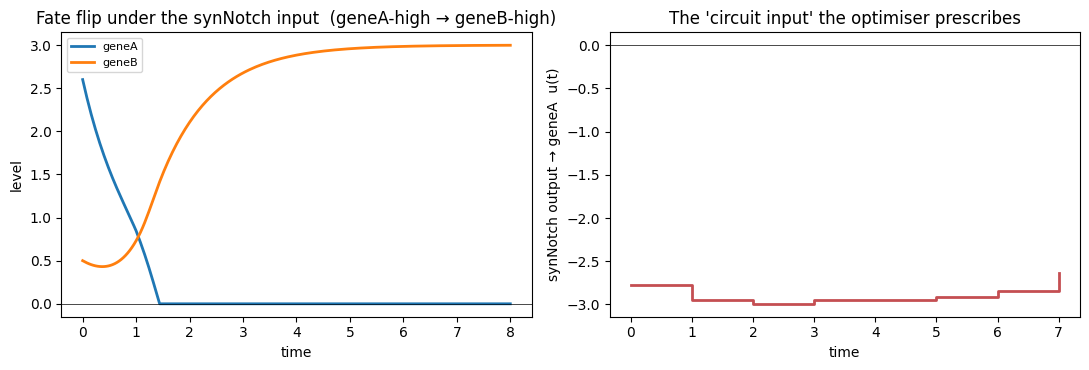

  → designing the actual circuit = choosing ligand/receptor (what triggers u), output gene (where u lands), threshold (the shape of u(signal)).


In [2]:
# --- readout: the Toda synNotch ON/OFF projection (committed) ---
if toda_json and toda_json.get("scores"):
    sc = np.array([s for s in toda_json["scores"] if all(np.isfinite(s))], float)   # (n_samples, 2): [score_axis0, score_axis1]
    # per-sample: which axis dominates (a crude "growth-like vs arrest-like" toggle readout)
    dom = sc[:, 1] - sc[:, 0]
    print(f"Toda synNotch samples projected into the Neocortex Atlas (n={len(sc)} finite of {len(toda_json['scores'])}):")
    print(f"  axis-1 minus axis-0 (per sample): mean {dom.mean():+.1f}  range [{dom.min():+.1f}, {dom.max():+.1f}]"
          f"  → the ON/OFF toggle separates the samples along this axis (growth-like ↔ arrest-like).")
else:
    print("[note] figures/toda_results.json absent — skipping the readout panel.")

# --- demo: a synNotch input that flips the toggle's fate ---
z_start = jnp.array([2.6, 0.5])                                       # deep in the geneA-high basin
useg, zf, L = fit_input_to_basin(z_start, target_basin="B")
print(f"\nsynNotch-toggle fate flip:  start (geneA={float(z_start[0]):.1f}, geneB={float(z_start[1]):.1f})  →  "
      f"end (geneA={zf[0]:.2f}, geneB={zf[1]:.2f})  "
      f"{'✓ flipped to the geneB-high fate' if zf[1] > zf[0] else '✗ still geneA-high'}")
print(f"  synNotch output schedule on geneA (the 'circuit input' u(t)): {np.round(U_MAX*np.tanh(np.asarray(useg)), 2)}")
def _traj(z0, useg, beta=3.0, theta_g=0.0):
    out = [np.asarray(z0)]; z = z0
    for i in range(NSTEP):
        seg = min(int(i*N_SEG/NSTEP), N_SEG-1)
        z = z + DT*(toggle(z, beta) + jnp.array([U_MAX*jnp.tanh(useg[seg]) + theta_g, 0.0])); z = jnp.maximum(z, 0.0)
        out.append(np.asarray(z))
    return np.array(out)
tr = _traj(z_start, useg); tt = np.linspace(0, NSTEP*DT, NSTEP+1)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(tt, tr[:, 0], lw=2, label="geneA"); ax[0].plot(tt, tr[:, 1], lw=2, label="geneB")
ax[0].axhline(0, lw=.5, color="k"); ax[0].set_xlabel("time"); ax[0].set_ylabel("level"); ax[0].legend(fontsize=8)
ax[0].set_title("Fate flip under the synNotch input  (geneA-high → geneB-high)")
ax[1].step(np.linspace(0, NSTEP*DT, N_SEG+1)[:-1], U_MAX*np.tanh(np.asarray(useg)), where="post", lw=2, color="#C44E52")
ax[1].axhline(0, lw=.5, color="k"); ax[1].set_xlabel("time"); ax[1].set_ylabel("synNotch output → geneA  u(t)")
ax[1].set_title("The 'circuit input' the optimiser prescribes")
fig.tight_layout(); plt.show()
print("  → designing the actual circuit = choosing ligand/receptor (what triggers u), output gene (where u lands), threshold (the shape of u(signal)).")

## 3. Scaffold & conformation — 3-D/4-D bioprinting (Feinberg/Lewis/Skylar-Scott/Gartner)

Print the cells in the right *places* — and, increasingly, in the right *time-evolving conformation*
(4-D: a printed shape that folds, contracts, or self-organises afterward). FRESH/CHIPS, SWIFT,
PRINTESS, DPAC + conformation control. Here the actuator is mostly a **static parameter** — the print
geometry / aspect ratio — so the control problem becomes *parameter optimisation*: choose $\theta_B$
(geometry) so the plant relaxes into the target tissue state. Same `jax.grad`-through-the-model,
no time-varying input. (Selecting *what* shape to target — the developmental anatomical reference — is its own literature; for *Xenopus*, the Zahn et al. 2017 stage-22–48 drawings [(Xenbase art. 53877)](https://www.xenbase.org/xenbase/literature/article.do?method=display&articleId=53877) are a high-quality, CC-BY-NC-licensed source of target morphologies.)

**Readout (committed).** `figures/gartner_results.json` — the conformation-controlled kidney organoid
(`scripts/benchmark_gartner_4d.py`; `man` = manual "dots", `r0`/`r40` = 4-D-printed "lines" of
increasing aspect ratio): projecting each onto fetal-kidney lineage-maturity markers, the **r40**
(high-aspect-ratio) conformation maximises proximal-tubule and podocyte maturity and minimises
off-target stroma — *print geometry → lineage maturity*, made quantitative. `system_maturity_results.json`
puts that in context across systems (organoid · bioprinted brain · bioprinted kidney · bioprinted liver
× progenitor / mature / excitatory axes).

**Demo.** The toggle plant, but now with a *static* geneA-nullcline shift $\theta_g$ (a stand-in for
"the conformation tilts the niche toward fate A or B"): from a fixed start, optimise $\theta_g$ so the
*free* relaxation (no time-varying input) lands in the target basin.


Gartner conformation-controlled kidney organoid — lineage-maturity scores (rows = print conformation):
      conformation   Loop of Henle        Podocyte  Proximal Tubul          Stroma
               man         -0.0043         -0.0624          0.0081         -0.0408
                r0         -0.0032         -0.0199          0.0003         -0.0301
               r40         -0.0013          0.0297          0.0164         -0.0121


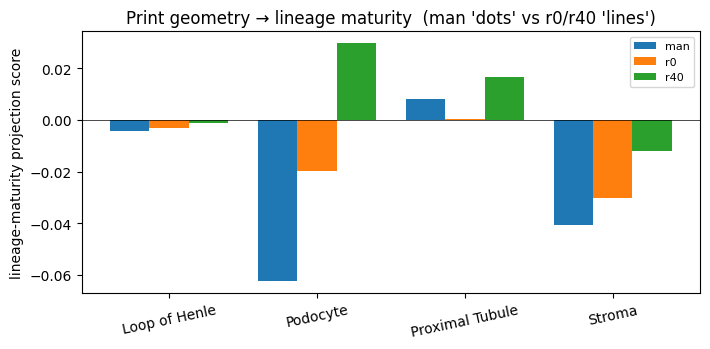

  → the highest-aspect-ratio conformation most boosts: Podocyte  (the §4 'print geometry is a design parameter' point).

'geometry'-parameter optimisation:  θ_g* = -0.878  →  free relaxation lands at (geneA=0.00, geneB=3.00)  ✓ in the geneB-high basin
  → a single static parameter, optimised through the model, biases which attractor the tissue self-organises into — that's the 4-D-printing control problem.


In [3]:
# --- readout: the Gartner conformation → lineage-maturity profile (committed) ---
if gartner_json:
    rows = gartner_json if isinstance(gartner_json, list) else gartner_json.get("rows", [])
    lineages = sorted({r["lineage"] for r in rows}); samples = sorted({r["sample"] for r in rows})
    M = np.array([[next(r["score"] for r in rows if r["lineage"] == ln and r["sample"] == sm) for ln in lineages] for sm in samples], float)
    print("Gartner conformation-controlled kidney organoid — lineage-maturity scores (rows = print conformation):")
    print("  " + "".join(f"{ln[:14]:>16}" for ln in (["conformation"] + lineages)))
    for sm, row in zip(samples, M):
        print("  " + f"{sm:>16}" + "".join(f"{v:>16.4f}" for v in row))
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    x = np.arange(len(lineages)); w = 0.8 / max(1, len(samples))
    for i, sm in enumerate(samples):
        ax.bar(x + (i - (len(samples)-1)/2)*w, M[i], w, label=sm)
    ax.set_xticks(x); ax.set_xticklabels(lineages, rotation=12); ax.axhline(0, lw=.5, color="k")
    ax.set_ylabel("lineage-maturity projection score"); ax.set_title("Print geometry → lineage maturity  (man 'dots' vs r0/r40 'lines')"); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()
    best = lineages[int(np.argmax(M[-1] - M[0]))] if len(samples) > 1 else lineages[0]
    print(f"  → the highest-aspect-ratio conformation most boosts: {best}  (the §4 'print geometry is a design parameter' point).")
else:
    print("[note] figures/gartner_results.json absent — skipping the conformation readout.")

# --- demo: optimise a static 'geometry' parameter to land in a target basin ---
def fit_geometry(z_start, target_basin="B", steps=200):
    tx, ty = (0.5, 2.6) if target_basin == "B" else (2.6, 0.5)
    def loss(tg):
        zf = toggle_roll(z_start, jnp.zeros(N_SEG), 3.0, tg)        # no time-varying input — just the geometry shift
        return (zf[0]-tx)**2 + (zf[1]-ty)**2 + 1e-2*tg**2
    tg = jnp.float32(0.0)
    if HAVE_OPTAX:
        o = optax.adam(0.05); s = o.init(tg)
        @jax.jit
        def st(t, ss): l, g = jax.value_and_grad(loss)(t); up, ss = o.update(g, ss); return optax.apply_updates(t, up), ss, l
        for _ in range(steps): tg, s, _ = st(tg, s)
    else:
        g = jax.jit(jax.grad(loss))
        for _ in range(steps): tg = tg - 0.02*g(tg)
    return float(tg), np.asarray(toggle_roll(z_start, jnp.zeros(N_SEG), 3.0, tg))
tg_star, zf_g = fit_geometry(jnp.array([2.0, 1.2]), target_basin="B")
print(f"\n'geometry'-parameter optimisation:  θ_g* = {tg_star:+.3f}  →  free relaxation lands at (geneA={zf_g[0]:.2f}, geneB={zf_g[1]:.2f})  "
      f"{'✓ in the geneB-high basin' if zf_g[1] > zf_g[0] else '✗ not yet — widen the search or lower the penalty'}")
print("  → a single static parameter, optimised through the model, biases which attractor the tissue self-organises into — that's the 4-D-printing control problem.")

## 4. Bioelectric control — the $V_{\rm mem}$ prepattern (Levin / Mafe; the BETSE-JAX refactor)

Endogenous **bioelectric** state — resting potentials $V_{\rm mem}$, gap-junctional coupling, ion
fluxes — carries *non-genetic patterning information*: a depolarisation pattern can act as a
**prepattern** that *triggers* downstream transcriptional and morphological programs (Levin 2014/2021;
Pietak & Levin 2017's $V_{\rm mem}$↔transcription coupling; the Mafe-group multicellular-cluster
models). The bioelectric layer is *another actuator* in the §4.3 menu: $B$ = a $V_{\rm mem}$ set-point /
an ion-channel conductance / a gap-junction connectivity, and the control problem is two-layer —
**bioelectric prepattern → regulatory program → tissue state**.

### What the actuator looks like — the canonical taxonomy

The single cleanest demonstration that *the same tissue* admits *categorically different morphologies*
under bioelectric tuning is Pietak & Levin 2018 Fig. 4, reproduced below on a 772-cell planarian mesh
using BETSE-JAX (`betse.science.jax`, sister repo `~/Workspace/betse-unified`):

![Pietak & Levin 2018 Fig 4 reproduced via BETSE-JAX — six categorical $V_{\rm mem}$ phenotypes on the same body plan](../figures/pietak_2018_reproduction.png)

> *Same silhouette, same ion-channel kinetics, same 6000-step integrator — six categorically different
> steady states. **(a)** wild-type AP gradient · **(b)** two-headed (both ends depolarised) ·
> **(c)** double-tail (both ends hyperpolarised) · **(d)** GJ-disrupted (patchy) ·
> **(e)** lateralised (DV gradient) · **(f)** mid-cut (GJ blocked across midline → two domains).
> The Levin lab's experimental literature realises (b)–(f) by transient ion-channel pharmacology;
> here they fall out of the simulator by tuning a handful of channel/GJ parameters. This is what
> "bioelectric prepattern" means concretely.*

### And the dynamics — a real-marker planarian GRN under bioelectric forcing

A 250-cell *Schmidtea mediterranea* mesh, 16 canonical markers (Fincher 2018 / Plass 2018 panel —
`smedwi-1/2`, `wnt1`, `notum`, `foxD`, `gata4-5-6`, `myoD`, …), HH-squid ion-channel kinetics from
BIOMD0000000020, integrated through `betse.science.jax.solver.stepper.step_pure`:

| start | mid | end |
|:---:|:---:|:---:|
| ![smed-start](../figures/planaria_smed_start.png) | ![smed-mid](../figures/planaria_smed_mid.png) | ![smed-end](../figures/planaria_smed_end.png) |

> *Anterior–posterior expression pattern resolves over the rollout. Each frame is a real-gene panel
> driven by the bioelectric state — that's the **two-layer control problem** ($V_{\rm mem}$ → GRN)
> in operation, not as a cartoon. (Source: `betse-unified/demo_planaria.yaml` → `RESULTS/planaria_smed.mp4`;
> the full movie shows the transition continuously.)*

### The differentiable sister stack

The **differentiable JAX/`diffrax` refactor of BETSE/BETSEE** lives at `~/Workspace/betse-unified`,
and `betse.science.jax.inverse.optimize_pattern` is *literally* the bioelectric anatomical compiler —
define a target voltage pattern, `jax.grad` to the required ion currents. A verified 10-cell
benchmark drives resting tissue into an alternating ±depolarisation pattern, loss $9\!\times\!10^{-4}
\to 1.4\!\times\!10^{-10}$. Bridge examples (each one optimal-control problem on the differentiable
plant): inverse bioelectric design / xenobot motility · $V_{\rm mem}$→GRN prepatterning ·
morphoceutical intervention timelines (Murugan 2022; Pio-Lopez & Levin 2023) · large-scale pattern
integration (Manicka, Pai & Levin 2023). See `REFERENCES.md` 38, 39a–39e.

### Demo (the regulome side, in-notebook)

The image grids above are the **actuator** side; below is the **regulome readout** side, on the
1-D toy you can rerun in 0.1 s. Couple a scalar "$V_{\rm mem}$ level" $v(t)$ to the regulatory plant
— $v$ biases `geneA`'s drift (a toy $V_{\rm mem}$→GRN map) — and ask the optimiser for the *voltage*
schedule that steers the cell to the target fate. (In the real two-layer pipeline `optimize_pattern`
supplies the ion currents that realise $v(t)$; here we just do the regulome layer — Lab 8's machinery
with $B$ = the 1-dim bioelectric handle.)


In [4]:
# the bioelectric handle = a v(t)→geneA-drift coupling (toy V_mem→GRN map); reuse fit_input_to_basin
z_start = jnp.array([2.6, 0.5])
useg_v, zf_v, _ = fit_input_to_basin(z_start, target_basin="B", lam=2e-2)   # 'useg_v' now reads as the V_mem schedule
v_schedule = U_MAX * np.tanh(np.asarray(useg_v))
print(f"bioelectric (toy) two-layer steer:  V_mem schedule {np.round(v_schedule, 2)}  →  "
      f"end (geneA={zf_v[0]:.2f}, geneB={zf_v[1]:.2f})  {'✓ fate switched' if zf_v[1] > zf_v[0] else '✗ not switched'}")
print("  → in the real pipeline: betse.science.jax.inverse.optimize_pattern finds the ion currents that produce this V_mem(t);")
print("    then the V_mem→GRN coupling (Pietak & Levin 2017) drives the regulome ODE — the §4.3(v) experiment, two layers, one gradient.")
print(f"  (sister project: ~/Workspace/betse-unified — BETSE_JAX=1 uv run pytest tests/betse_test/a00_unit/science/test_jax_inverse.py)")

bioelectric (toy) two-layer steer:  V_mem schedule [-3.   -3.08 -3.1  -3.04 -3.04 -3.02 -2.97 -2.81]  →  end (geneA=0.00, geneB=3.00)  ✓ fate switched
  → in the real pipeline: betse.science.jax.inverse.optimize_pattern finds the ion currents that produce this V_mem(t);
    then the V_mem→GRN coupling (Pietak & Levin 2017) drives the regulome ODE — the §4.3(v) experiment, two layers, one gradient.
  (sister project: ~/Workspace/betse-unified — BETSE_JAX=1 uv run pytest tests/betse_test/a00_unit/science/test_jax_inverse.py)


## 5. Agential materials & biobots — specify a goal, not a recipe (Levin/Bongard; Gumuskaya)

**Xenobots** (Kriegman et al. 2020/2021 — frog-cell collectives whose *shape* was designed by an
evolutionary algorithm in simulation, then built) and **anthrobots** (Gumuskaya et al. 2024 — motile
multicellular bots that *self-construct* from adult human airway-epithelial progenitors) are the
purest statement of Davies's premise: you don't micro-manage the cells, you set a **goal** (a target
motility, a target shape) and let their competencies fill it in. As a control problem the actuator $B$
is "the cell-collective's contraction / motility goals", and the design move is **inverse design** —
gradient-descend the goals to hit the target behaviour. **BETSE-JAX now does exactly this** for the
bioelectric layer: `betse.science.jax.physics.motility` (bioelectric force → movement; `test_jax_xenobot.py`)
replaces the evolutionary search (xenobots) with gradient descent on the cell-collective's force/motility
goals — the JAX engine is the right substrate for it.

**Readout (committed).** `figures/anthrobot_results.json` (`scripts/benchmark_anthrobot_fidelity.py`):
the anthrobot samples scored for a *motility transcriptional signature* (cilia/ECM/cytoskeleton
programs) — `motility_mean ≈ -0.02`, ~236 inferred regulatory modules — i.e. the instrument reads
*which regulatory programs the biobot is running*, which is what you'd close an inverse-design loop on.
The "agential" twist also lands on Lab 8's point: it's the **flow** you steer toward a goal, not the
microscopic parameters — the cells own those.

In [5]:
if anthro_json:
    print(f"Anthrobot fidelity readout ({anthro_json.get('n_cells'):,} cells, {anthro_json.get('n_genes'):,} genes; samples {anthro_json.get('samples')}):")
    print(f"  motility transcriptional signature: mean z-score {anthro_json.get('motility_mean'):+.3f}   |   inferred regulatory modules: {anthro_json.get('n_modules')}")
    print("  → the instrument reads *which regulatory programs* the biobot runs; inverse design would gradient-descend the")
    print("    cell-collective's motility/contraction goals to hit a target — replacing the evolutionary search (xenobots) with jax.grad.")
else:
    print("[note] figures/anthrobot_results.json absent — see scripts/benchmark_anthrobot_fidelity.py.")
# the four-system readiness picture (advanced fidelity / maturity) as the cross-cutting readout
if advfid_json:
    ds = sorted({r["dataset"] for r in advfid_json}); pat = sorted({r["pattern"] for r in advfid_json})
    M = np.array([[next(r["score"] for r in advfid_json if r["dataset"] == d and r["pattern"] == p) for p in pat] for d in ds], float)
    Mn = M / M.sum(1, keepdims=True)
    print("\nfidelity-of-identity readout — normalised pattern profile per engineered system (rows sum to 1):")
    print("  " + "".join(f"{p[:16]:>18}" for p in (["system"] + pat)))
    for d, row in zip(ds, Mn):
        print("  " + f"{d:>18}" + "".join(f"{v:>18.1%}" for v in row))
    print("  → 'did the engineered tissue light up the right programs?' — across modalities, one readout. (Exercise (d): turn this into a readiness score.)")

Anthrobot fidelity readout (90,083 cells, 61,860 genes; samples ['S1', 'S2']):
  motility transcriptional signature: mean z-score -0.021   |   inferred regulatory modules: 236
  → the instrument reads *which regulatory programs* the biobot runs; inverse design would gradient-descend the
    cell-collective's motility/contraction goals to hit a target — replacing the evolutionary search (xenobots) with jax.grad.

fidelity-of-identity readout — normalised pattern profile per engineered system (rows sum to 1):
              system     Mature Neuron  Outer Radial Gli    Synaptic (ASD)
  Bioprinted Brain (Tang)             34.4%             37.6%             28.0%
  Bioprinted Liver (Zhang)             13.5%             48.6%             37.9%
    Organoid (Fleck)             38.4%             36.7%             24.9%
  hiPSC-NSC (Vassal)             36.9%             38.2%             24.9%
  → 'did the engineered tissue light up the right programs?' — across modalities, one readout. (Exerc

## 6. The model-in-the-loop design cycle

Putting the pieces together — the loop the whitepaper's §4.3 is built to run:

1. **Design** — pick a target tissue state and an actuator $B$ (which modality: synNotch · print
   geometry · $V_{\rm mem}$ · biobot goals).
2. **Simulate** — the plant: a Hypergraph Neural ODE on the relevant regulome ([Lab 5](05_hypergraph_neural_odes.ipynb)),
   or — for the bioelectric layer — the BETSE-JAX solver.
3. **Optimise** — the controller: direct optimal control / parameter optimisation, `jax.grad`
   through the solve ([Lab 8](08_anatomical_compiler.ipynb); BETSE-JAX `optimize_pattern`) — out comes
   the actuation schedule / the circuit spec / the print geometry / the ion-current profile.
4. **Build** — the wet lab (Lim/Gartner/Feinberg/Lewis/Levin labs and the platforms above).
5. **Read out** — *did it execute the intended program?* The fidelity triple ([Lab 3](03_benchmarking_fidelity.ipynb)),
   the Module Identifiability Index ([Lab 4](04_modularity_identifiability.ipynb)), driver stability
   ([Lab 5](05_hypergraph_neural_odes.ipynb)), the pattern projections — *and* a spatial/mechanical
   readout (a cell-based simulator) and a bioelectric readout (BETSE) for the layers this instrument
   doesn't model.
6. **Refine** — update the plant and the target; repeat.

**What's real vs aspirational.** The *readouts* are built and benchmarked — every panel above is a
committed result on a real dataset (Toda synNotch, Gartner conformation, anthrobots, the four
engineered-system fidelity/maturity profiles). The *controllers* are demonstrated (Lab 8; the
BETSE-JAX bridge examples are all implemented & verified). What's the **programme**, not done: closing the loop
*with wet-lab design in it*, and — the deepest gap — the map from a *regulome state* to an *anatomy*
(Lab 8 §4). This lab is the agenda; the previous eight are the down payment.

## 7. Exercises

**(a) Design a synNotch circuit, end to end.** Extend §2: model the *sender* fraction $\phi$ (what
fraction of neighbours present the ligand) → a graded synNotch output $u = u_{\max}\,g(\phi)$ (a Hill
law with a tunable threshold $K$ and a tunable output-gene wiring), feeding the plant. Find the
$(K,\text{wiring})$ — and the minimal sender fraction $\phi^\star$ — that flips a receiver cell's fate.
That's the actual circuit-design problem (Morsut 2016 / Toda 2018 made it physical).

**(b) Multi-dimensional print geometry.** Extend §3: let $\theta_B\in\mathbb R^k$ parametrise more of
the conformation (aspect ratio, curvature, a gradient direction), each entering the plant's drift, and
optimise $\theta_B$ to a *target lineage mixture* (a probability vector over fates), with a printability
constraint. Reproduce the Gartner finding qualitatively — does the optimum favour high aspect ratio for
"more proximal tubule, less stroma"?

**(c) The full two-layer bioelectric→GRN compiler.** Couple BETSE-JAX's `optimize_pattern` (it gives
you the ion currents for a target $V_{\rm mem}$ map) to a $V_{\rm mem}$→drift map and then to the
regulome ODE; run Lab 8's optimal control with the bioelectric set-point as $B$. (Plant code:
`~/Workspace/betse-unified`, `betse.science.jax.inverse`; the regulome layer: this notebook /
[Lab 8](08_anatomical_compiler.ipynb).) This is the §4.3(v) experiment in silico.

**(d) A "readiness" score.** Combine the readouts into one number per engineered system $\times$ target:
fidelity triple (Lab 3: in-domain r, transfer direction-accuracy, transfer r) $+$ Module
Identifiability Index (Lab 4) $+$ driver stability (Lab 5: how concentrated is the rollout-MSE mass in
the homeostatic drivers). Compute it for the four systems in `system_maturity_results.json` /
`advanced_fidelity_results.json`. Which is "most ready" for which target — and what does the score say
to *change* first?

**(e) Close the loop on a real dataset (paper exercise).** Pick one — Toda 2020 (synNotch), Gartner
(conformation), or the anthrobots — and write the full design→simulate→optimise→build→read-out→refine
cycle: name the actuator $B$, the target state, the plant, the controller, the readout, and the *one
thing you'd change on iteration 2*. (No code — this is the experimental-design exercise the course is
ultimately for.)

Starter for (a)/(b):

In [6]:
# --- Exercise (a)/(b) starter: a graded synNotch input from a sender fraction; and multi-θ geometry ----
def synnotch_output(phi, u_max=U_MAX, K=0.4, hill=3.0):
    """sender fraction φ → synNotch output (Hill-activating)."""
    return u_max * phi**hill / (K**hill + phi**hill)
def fit_sender_fraction(z_start, target_basin="B", K=0.4, steps=200):
    """Find the minimal constant sender fraction φ that flips the fate (a constant input = synnotch_output(φ))."""
    tx, ty = (0.5, 2.6) if target_basin == "B" else (2.6, 0.5)
    def loss(raw):
        phi = jax.nn.sigmoid(raw)                                    # φ ∈ (0,1)
        u_const = -synnotch_output(phi, K=K)                         # drive geneA down (toward basin B)
        useg = jnp.full((N_SEG,), jnp.arctanh(jnp.clip(u_const/U_MAX, -0.999, 0.999)))
        zf = toggle_roll(z_start, useg)
        return (zf[0]-tx)**2 + (zf[1]-ty)**2 + 0.3*phi               # + a small "use less ligand" penalty → minimal φ
    raw = jnp.float32(0.0)
    if HAVE_OPTAX:
        o = optax.adam(0.2); s = o.init(raw)
        @jax.jit
        def st(r, ss): l, g = jax.value_and_grad(loss)(r); up, ss = o.update(g, ss); return optax.apply_updates(r, up), ss, l
        for _ in range(steps): raw, s, _ = st(raw, s)
    phi_star = float(jax.nn.sigmoid(raw))
    u_c = -float(synnotch_output(phi_star, K=K))
    zf = np.asarray(toggle_roll(z_start, jnp.full((N_SEG,), float(jnp.arctanh(jnp.clip(jnp.float32(u_c/U_MAX), -0.999, 0.999))))))
    return phi_star, zf
phi_star, zf_s = fit_sender_fraction(jnp.array([2.6, 0.5]), K=0.4)
print(f"minimal sender fraction to flip the fate (synNotch threshold K=0.4):  φ* ≈ {phi_star:.2f}  →  end (geneA={zf_s[0]:.2f}, geneB={zf_s[1]:.2f})  "
      f"{'✓ flipped' if zf_s[1] > zf_s[0] else '✗ — lower K or raise u_max'}")
print("  → your turn: (a) sweep K and the output-gene wiring — how does φ* depend on the threshold?  (b) make θ_g multi-dim (a vector of geometry params) and target a fate *mixture*.")

minimal sender fraction to flip the fate (synNotch threshold K=0.4):  φ* ≈ 0.81  →  end (geneA=0.00, geneB=3.00)  ✓ flipped
  → your turn: (a) sweep K and the output-gene wiring — how does φ* depend on the threshold?  (b) make θ_g multi-dim (a vector of geometry params) and target a fate *mixture*.


## Recap & where this sits

- The §4.3 forward programme of synthetic morphology is **one optimal-control problem on the
  Hypergraph Neural ODE**, instantiated four ways — *programmed* (synNotch / synthetic morphogens —
  Lim/Morsut/Toda), *printed* (conformation / 4-D bioprinting — Feinberg/Lewis/Skylar-Scott/Gartner),
  *bioelectric* ($V_{\rm mem}$ prepattern — Levin/Mafe; the (now complete) BETSE-JAX refactor), and *agential*
  (xenobots/anthrobots — Levin/Bongard; Gumuskaya) — differing only in the actuator $B$, whether the
  handle is an input or a static parameter, and which readout layer closes the loop.
- The instrument supplies the readout — *did the engineered tissue execute its intended program?* — via
  the fidelity triple ([Lab 3](03_benchmarking_fidelity.ipynb)), the Module Identifiability Index
  ([Lab 4](04_modularity_identifiability.ipynb)), driver stability ([Lab 5](05_hypergraph_neural_odes.ipynb)),
  and the pattern projections; the controller supplies the actuation ([Lab 8](08_anatomical_compiler.ipynb);
  BETSE-JAX `optimize_pattern`). The closed model-in-the-loop *design* cycle, and the regulome→anatomy
  map, are the open frontier.
- **Next (and last):** [Lab 10 — Cancer as loss of module identifiability](README.md) — the same metrics,
  turned diagnostic: run the Module Identifiability Index and the driver-stability split down a
  primary → organoid → tumour-organoid → cancer-line gradient, and reframe therapy (the anatomical
  compiler) as *steer the cell back into a differentiated attractor*, not just kill it.
- Pipeline / pointers: `scripts/benchmark_{toda_morphogenesis,gartner_4d,anthrobot_fidelity,advanced_fidelity,
  system_maturity}.py`; the bioelectric companion at `~/Workspace/betse-unified` (`betse.science.jax.inverse`);
  the bioprinting / synNotch / bioelectric references in `REFERENCES.md`; Davies 2008 and Solé et al.
  2024 for the framing.